# Phân tích và khám phá dữ liệu (EDA)
Bộ dữ liệu: **Dry Bean Dataset** - file `Dry_Bean_Dataset.xlsx`

## Giới thiệu bộ dữ liệu:
Bộ dữ liệu **Dry Bean Dataset** ghi nhận thông tin đặc trưng hình học của các hạt đậu khô, được thu thập thông qua hệ thống computer vision từ ảnh chụp độ phân giải cao. Dữ liệu phục vụ cho bài toán phân loại các loại đậu khác nhau dựa trên hình dạng và kích thước.

## Thông tin chi tiết:
* **Tập dữ liệu sử dụng:** Tập dữ liệu sử dụng: Gồm 13.611 mẫu (hạt đậu).

* **Biến mục tiêu (Target):** `Class` (7 loại đậu: `Seker`, `Barbunya`, `Bombay`, `Cali`, `Dermosan`, `Horoz`, `Sira`).

* **Các đặc trưng (Features):**
Bao gồm 16 đặc trưng số học, được chia thành:

  - **Đặc trưng kích thước:** diện tích, chu vi, trục lớn/nhỏ,...

  - **Đặc trưng hình dạng:** độ tròn, độ gọn, độ lệch tâm, các hệ số hình dạng,... 


  Cụ thể như sau:
    1. `Area` (A): Diện tích vùng hạt (số pixel)

    2. `Perimeter` (P): Chu vi của hạt

    3. `MajorAxisLength` (L): Độ dài trục lớn nhất

    4. `MinorAxisLength` (l): Độ dài trục nhỏ nhất (vuông góc với trục lớn)

    5. `AspectRatio` (K): Tỷ lệ giữa trục lớn và trục nhỏ (L/l)

    6. `Eccentricity` (Ec): Độ lệch tâm của elip tương đương

    7. `ConvexArea` (C): Diện tích bao lồi nhỏ nhất chứa hạt

    8. `EquivalentDiameter` (Ed): Đường kính của hình tròn có cùng diện tích

    9. `Extent` (Ex): Tỷ lệ diện tích hạt so với bounding box

    10. `Solidity` (S): Tỷ lệ giữa diện tích hạt và diện tích bao lồi

    11. `Roundness` (R): Độ tròn của hạt

    12. `Compactness` (CO): Độ “gọn” của hình (Ed/L)

    13. `ShapeFactor1` (SF1)

    14. `ShapeFactor2` (SF2)

    15. `ShapeFactor3` (SF3)

    16. `ShapeFactor4` (SF4)

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# Xác định ROOT: thư mục chứa 'data/'
try:
    ROOT = Path(__file__).resolve().parent.parent
except NameError:
    cwd = Path.cwd()
    for candidate in [cwd, cwd.parent, cwd.parent.parent]:
        if (candidate / "data").exists():
            ROOT = candidate
            break
    else:
        raise FileNotFoundError(f"Không tìm thấy thư mục 'data/' từ {cwd}")

DATA_DIR = ROOT / "data" / "classification"

print(f"ROOT     : {ROOT}")
print(f"DATA_DIR : {DATA_DIR}")
assert (DATA_DIR / "Dry_Bean_Dataset.xlsx").exists(), f"Không tìm thấy {DATA_DIR / 'Dry_Bean_Dataset.xlsx'}"

plt.rcParams["figure.dpi"] = 120

ROOT     : e:\MyProject\lab1-intro2ML
DATA_DIR : e:\MyProject\lab1-intro2ML\data\classification


## 1. Đọc và tổng quan dữ liệu

In [4]:
df = pd.read_excel(DATA_DIR / "Dry_Bean_Dataset.xlsx")
print(f"Kích thước: {df.shape[0]} mẫu, {df.shape[1]} cột")
df.head()

Kích thước: 13611 mẫu, 17 cột


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

Kiểm tra giá trị thiếu:

In [6]:
missing = df.isnull().sum()
print("Số giá trị thiếu theo cột:")
print(missing[missing > 0] if missing.any() else "Không có giá trị thiếu.")

Số giá trị thiếu theo cột:
Không có giá trị thiếu.


## 2. Thống kê mô tả:


In [7]:
FEATURES = ["Area", "Perimeter", "MajorAxisLength", "MinorAxisLength", 
            "AspectRation", "Eccentricity", "ConvexArea", "EquivDiameter", 
            "Extent", "Solidity", "roundness", "Compactness", "ShapeFactor1",
            "ShapeFactor2", "ShapeFactor3", "ShapeFactor4"]
TARGET = "Class"

stat = stat = df[FEATURES].describe().T[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
]
stat.columns = ["Trung bình", "Độ lệch chuẩn", "Min", "Q1", "Trung vị", "Q3", "Max"]
stat.round(4)

,Trung bình,Độ lệch chuẩn,Min,Q1,Trung vị,Q3,Max
Area,53048.2845,29324.0957,20420.0000,36328.0000,44652.0000,61332.0000,254616.0000
Perimeter,855.2835,214.2897,524.7360,703.5235,794.9410,977.2130,1985.3700
MajorAxisLength,320.1419,85.6942,183.6012,253.3036,296.8834,376.4950,738.8602
MinorAxisLength,202.2707,44.9701,122.5127,175.8482,192.4317,217.0317,460.1985
AspectRation,1.5832,0.2467,1.0249,1.4323,1.5511,1.7071,2.4303
Eccentricity,0.7509,0.0920,0.2190,0.7159,0.7644,0.8105,0.9114
ConvexArea,53768.2002,29774.9158,20684.0000,36714.5000,45178.0000,62294.0000,263261.0000
EquivDiameter,253.0642,59.1771,161.2438,215.0680,238.4380,279.4465,569.3744
Extent,0.7497,0.0491,0.5553,0.7186,0.7599,0.7869,0.8662
Solidity,0.9871,0.0047,0.9192,0.9857,0.9883,0.9900,0.9947


## 3. Phân bố biến mục tiêu Class

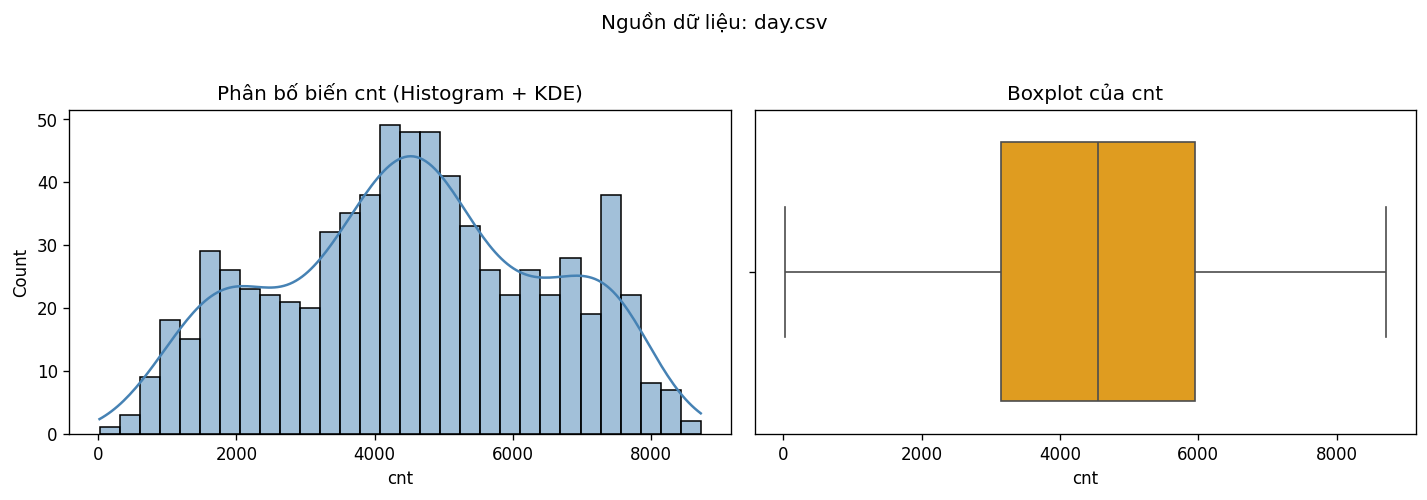

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64

In [ ]:
class_counts = df["Class"].value_counts().sort_values(ascending=False)
class_ratio = (class_counts / class_counts.sum() * 100).round(2)

plt.figure(figsize=(9, 5))
ax = sns.countplot(
    data=df,
    x="Class",
    order=class_counts.index,
    palette="Set2"
 )
ax.set_title("Phân bố biến Class")
ax.set_xlabel("Class")
ax.set_ylabel("Số lượng mẫu")
plt.xticks(rotation=25)

for i, cls_name in enumerate(class_counts.index):
    count = class_counts[cls_name]
    ratio = class_ratio[cls_name]
    ax.text(i, count + 20, f"{count} ({ratio}%)", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

pd.DataFrame({
    "Số lượng": class_counts,
    "Tỷ lệ (%)": class_ratio
})